## Importando los datos

In [71]:
import pandas as pd

df_movies = pd.read_csv("/kaggle/input/movie-recommendation-system/movies.csv")
df_ratings = pd.read_csv("/kaggle/input/movie-recommendation-system/ratings.csv")

In [3]:
print(df_movies.head())
print(df_movies.info())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB
None


In [4]:
print(df_ratings.head())
print(df_ratings.info())

   userId  movieId  rating   timestamp
0       1      296     5.0  1147880044
1       1      306     3.5  1147868817
2       1      307     5.0  1147868828
3       1      665     5.0  1147878820
4       1      899     3.5  1147868510
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB
None


## Extrayendo la proporcion de cada 

In [5]:
proportions = []
for value in df_ratings["rating"].unique():
    unique_rating = df_ratings.loc[df_ratings["rating"]==value]
    prop = len(unique_rating)/len(df_ratings)
    sample = unique_rating.sample(frac=prop)
    if len(sample) > 1000:
        proportions.append(sample)
    else:
        print(f"El puntaje: {value} contiene pocos valores")

df_ratings_filtered = pd.concat(proportions, axis=0)

### Uniendo el dataframe de puntajes (ratings) con el dataframe de películas (movies)

In [13]:
ratings_movies_merge = pd.merge(df_ratings_filtered, df_movies, on="movieId", how="inner")
ratings_movies_merge = ratings_movies_merge[["userId", "movieId", "title", "rating", "genres"]]
print(ratings_movies_merge.head())

   userId  movieId                                 title  rating  \
0   50370      595           Beauty and the Beast (1991)     5.0   
1  116192    98797                        Barbara (2012)     5.0   
2  136385    72720                  Single Man, A (2009)     5.0   
3  117236    70661  Tyler Perry's Meet the Browns (2008)     5.0   
4  125215     1272                         Patton (1970)     5.0   

                                            genres  
0  Animation|Children|Fantasy|Musical|Romance|IMAX  
1                                            Drama  
2                                            Drama  
3                             Comedy|Drama|Romance  
4                                        Drama|War  


## Estandarizando los títulos y géneros

In [14]:
import re

def clean_title(title: str) -> pd.Series:
    return re.sub("[^a-zA-Z0-9 ]", "", title)

In [15]:
ratings_movies_merge["title"] = ratings_movies_merge["title"].apply(lambda x: clean_title(x))
ratings_movies_merge["genres"] = ratings_movies_merge["genres"].str.split("|")

### Géneros únicos identificados

In [17]:
pd.Series([genero for lista_genero in ratings_movies_merge["genres"] for genero in lista_genero]).unique()

array(['Animation', 'Children', 'Fantasy', 'Musical', 'Romance', 'IMAX',
       'Drama', 'Comedy', 'War', 'Action', 'Horror', 'Sci-Fi',
       'Adventure', 'Crime', 'Thriller', 'Film-Noir', 'Mystery',
       'Western', 'Documentary', '(no genres listed)'], dtype=object)

## Excluyendo a las películas que no fueron asignados un género

In [28]:
genres_in = ratings_movies_merge[ratings_movies_merge["genres"].apply(lambda x: '(no genres listed)' not in x)]
pd.Series([genero for lista_genero in genres_in["genres"] for genero in lista_genero]).unique()

array(['Animation', 'Children', 'Fantasy', 'Musical', 'Romance', 'IMAX',
       'Drama', 'Comedy', 'War', 'Action', 'Horror', 'Sci-Fi',
       'Adventure', 'Crime', 'Thriller', 'Film-Noir', 'Mystery',
       'Western', 'Documentary'], dtype=object)

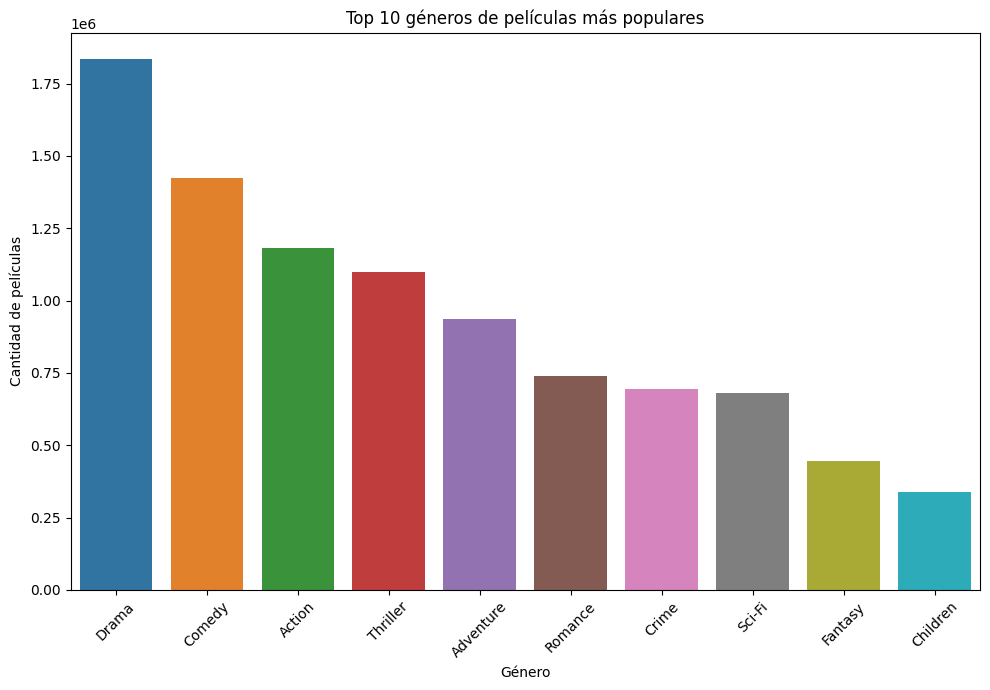

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

generos_peliculas = pd.Series([genero for lista_genero in genres_in["genres"] for genero in lista_genero])
top_generos = generos_peliculas.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_generos.index, y=top_generos.values, ax=ax)
plt.xticks(rotation=45)
plt.title("Top 10 géneros de películas más populares")
plt.xlabel("Género")
plt.ylabel("Cantidad de películas")
plt.tight_layout()
plt.show()

In [41]:
unique_genres = genres_in.explode("genres")

## Análisis de los datos

### Promedio de puntaje (rating) por película

In [36]:
print(genres_in.groupby("title")["rating"].mean().reset_index().sort_values(by="rating", ascending=False).head(10))

                                             title  rating
0                                             1961     5.0
1003   Adventures of Mowgli Return to Mankind 1971     5.0
11877            Hamtaro The Captive Princess 2002     5.0
11876                                  Hamsun 1996     5.0
11848               Halloween is Grinch Night 1977     5.0
11829                               Halla Bol 2008     5.0
20360     Onmyoji Onmyoji The Yin Yang Master 2001     5.0
11777                                    H8RZ 2015     5.0
20378                              Opera Jawa 2006     5.0
29219                              The Thirst 2007     5.0


### Top de audiencia por película

In [37]:
print(genres_in.groupby("title")["rating"].count().sort_values(ascending=False).head(10))

title
Forrest Gump 1994                        13896
Shawshank Redemption The 1994            13290
Pulp Fiction 1994                        12982
Silence of the Lambs The 1991            12903
Matrix The 1999                          11896
Jurassic Park 1993                       11504
Star Wars Episode IV  A New Hope 1977    11373
Toy Story 1995                           10335
Terminator 2 Judgment Day 1991           10264
Schindlers List 1993                     10199
Name: rating, dtype: int64


### Top 3 de películas por género

In [61]:
print(unique_genres.groupby(["genres", "title"])["rating"].mean().reset_index()\
.sort_values(["genres", "rating"], ascending=[True, False])\
.groupby("genres").head(3).reset_index(drop=True))

         genres                                         title    rating
0        Action                                        1 2014  5.000000
1        Action                       40 Days and Nights 2012  5.000000
2        Action                     A Place in the World 1992  5.000000
3     Adventure                       40 Days and Nights 2012  5.000000
4     Adventure   Adventures of Mowgli Return to Mankind 1971  5.000000
5     Adventure                    Ator the Iron Warrior 1987  5.000000
6     Animation   Adventures of Mowgli Return to Mankind 1971  5.000000
7     Animation                              Alois Nebel 2011  5.000000
8     Animation                          Back To The Sea 2012  5.000000
9      Children  12 Dogs of Christmas Great Puppy Rescue 2012  5.000000
10     Children                    12 Gifts of Christmas 2015  5.000000
11     Children                            Ace of Hearts 2008  5.000000
12       Comedy                                          1961  5

## Proceso de tokenización de títulos y filtrado de stopwords

In [72]:
df_movies["genres"] = df_movies["genres"].str.split("|")
df_movies_in = df_movies[df_movies["genres"].apply(lambda x: '(no genres listed)' not in x)]

In [75]:
from nltk.corpus import stopwords
from nltk.tokenize import wordpunct_tokenize
import nltk
# nltk.download('punkt')
# nltk.download('stopwords')
titulos = df_movies_in["title"]
#tokenizar los titulos (aplicado individualmente a cada título)
tokens_titulos = titulos.apply(wordpunct_tokenize)
# obteniendo la lista de stopwords en ingles
stop_words = set(stopwords.words('english'))
# filtrando los stopwords de cada título tokenizado
filtered_titles = tokens_titulos.apply(
    lambda token_titulo: " ".join([word for word in token_titulo if word.lower() not in stop_words])
)
filtered_titles.head()

0               Toy Story ( 1995 )
1                 Jumanji ( 1995 )
2        Grumpier Old Men ( 1995 )
3          Waiting Exhale ( 1995 )
4    Father Bride Part II ( 1995 )
Name: title, dtype: object

## Vectorización de títulos y similitud coseno

In [76]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

vectorizer = TfidfVectorizer(ngram_range=(1, 2))
vectorizer_titles = vectorizer.fit_transform(filtered_titles)

def busqueda_titulo(titulo: str) -> pd.DataFrame:
    titulo = clean_title(titulo)
    query_title = vectorizer.transform([titulo])
    similitud = cosine_similarity(vectorizer_titles, query_title).flatten()
    indices = np.argpartition(similitud, -5)[-5:]
    resultados = df_movies_in.iloc[indices][::-1]
    return resultados

## Búsqueda de títulos similares

In [82]:
resultados_peliculas = busqueda_titulo("interstellar")
print(resultados_peliculas["title"].reset_index(drop=True))

0                   Interstellar (2014)
1    The Science of Interstellar (2014)
2                  Visitors, The (1972)
3           Excuse Me for Living (2012)
4              Sea of Grass, The (1947)
Name: title, dtype: object
